[🎥 L17.5 A Variational Autoencoder for Handwritten Digits in PyTorch (23:12)](https://www.youtube.com/watch?v=afNuE5z2CQ8)


# Convolutional Variational Autoencoder for MNIST

### Imports

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

#### Import utility functions

In [2]:
from helper_data import get_dataloaders_mnist
from helper_train import train_vae_v1
from helper_utils import set_deterministic, set_all_seeds
from helper_plotting import plot_training_loss
from helper_plotting import plot_generated_images
from helper_plotting import plot_latent_space_with_labels
from helper_plotting import plot_images_sampled_from_vae

#### Settings

In [21]:
# Device
CUDA_DEVICE_NUM = 0
DEVICE = torch.device(f'cuda:{CUDA_DEVICE_NUM}' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# Hyperparameters
RANDOM_SEED = 123
LEARNING_RATE = 0.0005
BATCH_SIZE = 256
NUM_EPOCHS = 50

NUM_CLASSES = 10

Device: cuda:0


## Dataset

In [10]:
train_loader, valid_loader, test_loader = get_dataloaders_mnist(
  batch_size=BATCH_SIZE,
  num_workers=2,
  validation_fraction=0. # no need validation set
)

In [11]:
# Checking the dataset
print('Training Set:\n')
for images, labels in train_loader:
  print('Image batch dimensions:', images.size())
  print('Image label dimensions:', labels.size())
  print(labels[:10])
  break

print('\nValidation Set:')
for images, labels in valid_loader:
  print('Image batch dimensions:', images.size())
  print('Image label dimensions:', labels.size())
  print(labels[:10])
  break

print('\nTesting Set:')
for images, labels in test_loader:
  print('Image batch dimensions', images.size())
  print('Image label dimensions:', labels.size())
  print(labels[:10])
  break

Training Set:

Image batch dimensions: torch.Size([256, 1, 28, 28])
Image label dimensions: torch.Size([256])
tensor([2, 3, 3, 0, 4, 3, 6, 6, 5, 3])

Validation Set:

Testing Set:
Image batch dimensions torch.Size([256, 1, 28, 28])
Image label dimensions: torch.Size([256])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


## Model

In [ ]:
class Reshape(nn.Module):
  def __init__(self, *args):
    super().__init__()
    self.shape = args
  
  def forward(self, x):
    return x.view(self.shape)
  
class Trim(nn.Module):
  def __init__(self, *args):
    super().__init__()
  
  def forward(self, x):
    return x[:, :, :28, :28]

class VAE(nn.Module):
  def __init__(self, *args):
    super().__init__()
    
    self.encoder = nn.Sequential(
      nn.Conv2d(1, 32, stride=(1, 1), kernel_size=(3, 3), padding=1),
      nn.LeakyReLU(0.01),
      nn.Conv2d(32, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
      nn.LeakyReLU(0.01),
      nn.Conv2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),
      nn.LeakyReLU(0.01),
      nn.Conv2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
      nn.Flatten(),
      #  torch.nn.Linear(3136, 2) # <- this is for undercomplete AE
    )  
    
    # 2 dimensional latent space is created
    # since this is VAE, we're going to work this mean vector and log variance vector
    self.z_mean = torch.nn.Linear(3136, 2)
    self.z_log_var = torch.nn.Linear(3136, 2)
    
    self.decoder = nn.Sequential(
      torch.nn.Linear(2, 3136),
      Reshape(-1, 64, 7, 7),
      nn.ConvTranspose2d(64, 64, stride=(1, 1), kernel_size=(3, 3), padding=1),
      nn.LeakyReLU(0.01),
      nn.ConvTranspose2d(64, 64, stride=(2, 2), kernel_size=(3, 3), padding=1),                
      nn.LeakyReLU(0.01),
      nn.ConvTranspose2d(64, 32, stride=(2, 2), kernel_size=(3, 3), padding=0),                
      nn.LeakyReLU(0.01),
      nn.ConvTranspose2d(32, 1, stride=(1, 1), kernel_size=(3, 3), padding=0), 
      Trim(),  # 1x29x29 -> 1x28x28
      nn.Sigmoid() # for MSE (defined in helper funcion train_vae_v1)
    )

  # encoding to 2 dimensional space
  def encoding_fn(self, x):
    x = self.encoder(x)
    z_mean, z_log_var = self.z_mean(x), self.z_log_var(x)
    encoded = self.reparameterize(z_mean, z_log_var)
    return encoded # returns z

  def reparameterize(self, z_mu, z_log_var):
    eps = torch.randn(z_mu.size(0), z_mu.size(1)).to(z_mu.get_device())
    z = z_mu + eps * torch.exp(z_log_var/2.) # torch.exp(z_log_var/2.) <- standard deviation
    return z

  def forward(self, x):
    x = self.encoder(x)
    z_mean, z_log_var = self.z_mean(x), self.z_log_var(x) # two vector
    encoded = self.reparameterize(z_mean, z_log_var) # reparameterization
    decoded = self.decoder(encoded)
    return encoded, z_mean, z_log_var, decoded

In [16]:
set_all_seeds(RANDOM_SEED)

model = VAE()
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)  

## Training

In [17]:
log_dict = train_vae_v1(num_epochs=NUM_EPOCHS, model=model,
                        optimizer=optimizer, device=DEVICE,
                        train_loader=train_loader,
                        skip_epoch_stats=True,
                        logging_interval=50)

/home/rise-racing/Desktop/JIUUOO/today-i-learned/autoencoders-generative-models/vae/helper_train.py:202: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  print('Epoch: %03d/%03d | Batch %04d/%04d | Loss: %.4f'


Epoch: 001/050 | Batch 0000/0234 | Loss: 183.5786
Epoch: 001/050 | Batch 0050/0234 | Loss: 56.7792
Epoch: 001/050 | Batch 0100/0234 | Loss: 51.9689
Epoch: 001/050 | Batch 0150/0234 | Loss: 52.7030
Epoch: 001/050 | Batch 0200/0234 | Loss: 48.2433
Time elapsed: 0.02 min
Epoch: 002/050 | Batch 0000/0234 | Loss: 48.1391
Epoch: 002/050 | Batch 0050/0234 | Loss: 46.9832
Epoch: 002/050 | Batch 0100/0234 | Loss: 45.3210
Epoch: 002/050 | Batch 0150/0234 | Loss: 43.1575
Epoch: 002/050 | Batch 0200/0234 | Loss: 44.7737
Time elapsed: 0.04 min
Epoch: 003/050 | Batch 0000/0234 | Loss: 43.6385
Epoch: 003/050 | Batch 0050/0234 | Loss: 41.4253
Epoch: 003/050 | Batch 0100/0234 | Loss: 43.5009
Epoch: 003/050 | Batch 0150/0234 | Loss: 42.1976
Epoch: 003/050 | Batch 0200/0234 | Loss: 43.9096
Time elapsed: 0.05 min
Epoch: 004/050 | Batch 0000/0234 | Loss: 43.2843
Epoch: 004/050 | Batch 0050/0234 | Loss: 41.3621
Epoch: 004/050 | Batch 0100/0234 | Loss: 41.9715
Epoch: 004/050 | Batch 0150/0234 | Loss: 41.9131

## Evaluation

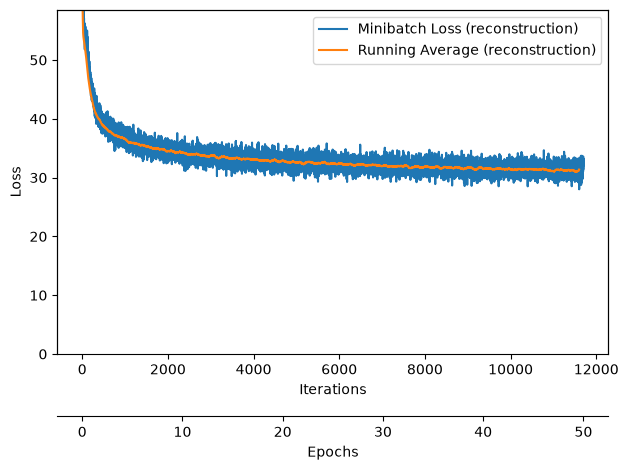

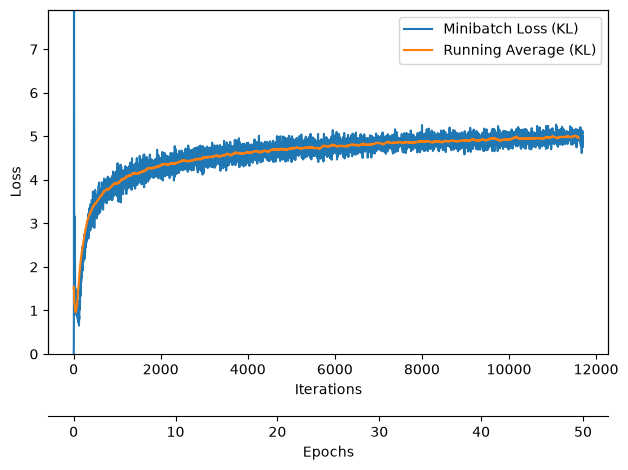

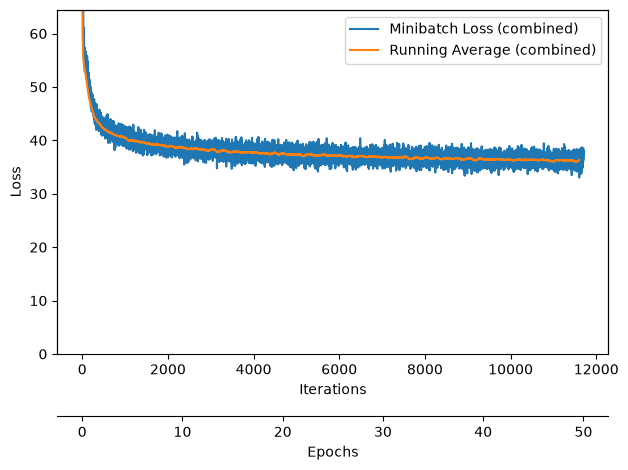

In [18]:
plot_training_loss(log_dict['train_reconstruction_loss_per_batch'], NUM_EPOCHS, custom_label=" (reconstruction)")
plot_training_loss(log_dict['train_kl_loss_per_batch'], NUM_EPOCHS, custom_label=" (KL)")
plot_training_loss(log_dict['train_combined_loss_per_batch'], NUM_EPOCHS, custom_label=" (combined)")
plt.show()

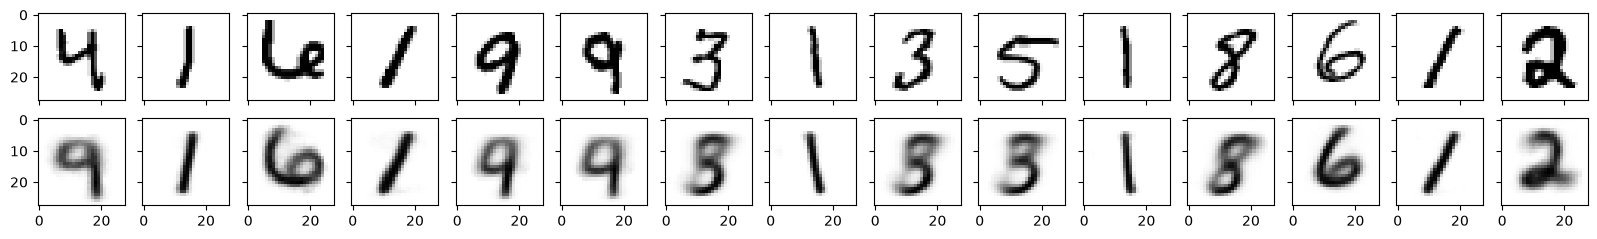

In [ ]:
plot_generated_images(data_loader=train_loader, model=model, device=DEVICE, modeltype='VAE')           
# first row: original images
# second row: reconstructed images

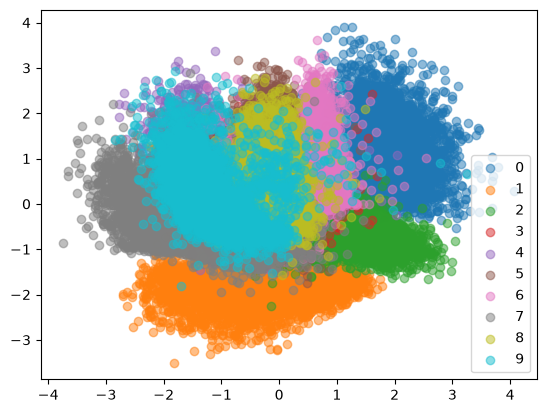

In [22]:
plot_latent_space_with_labels(
    num_classes=NUM_CLASSES,
    data_loader=train_loader,
    encoding_fn=model.encoding_fn, 
    device=DEVICE)

plt.legend()
plt.show()

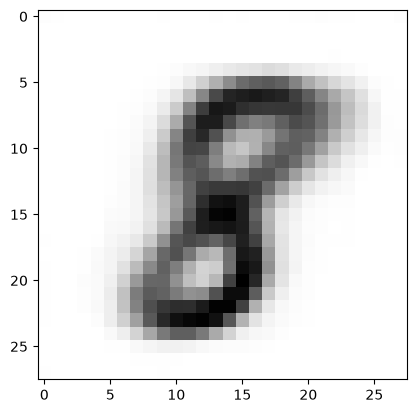

In [23]:
with torch.no_grad():
    new_image = model.decoder(torch.tensor([-0.0, 0.03]).to(DEVICE))
    new_image.squeeze_(0)
    new_image.squeeze_(0)
plt.imshow(new_image.to('cpu').numpy(), cmap='binary')
plt.show()

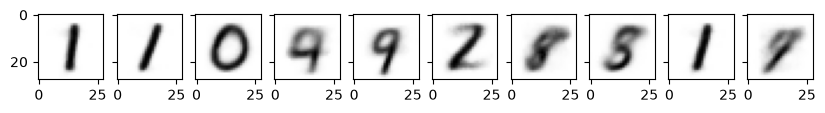

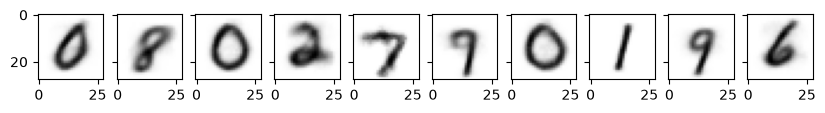

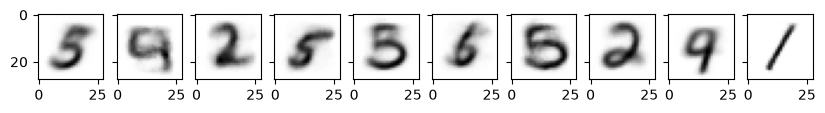

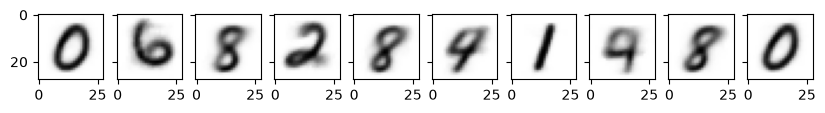

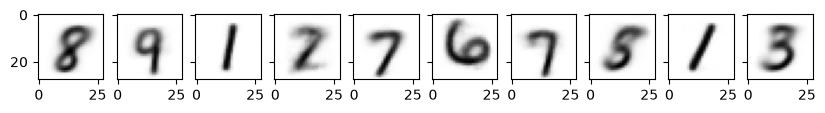

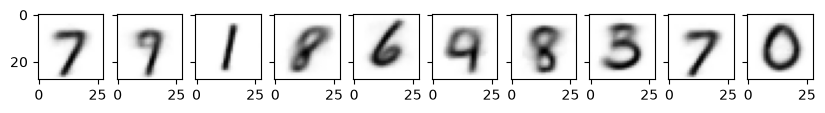

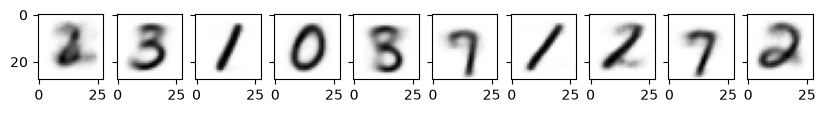

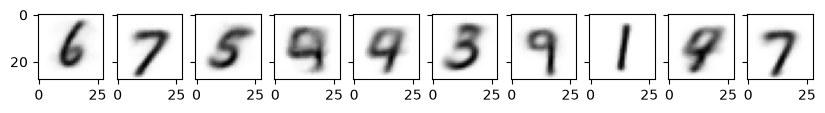

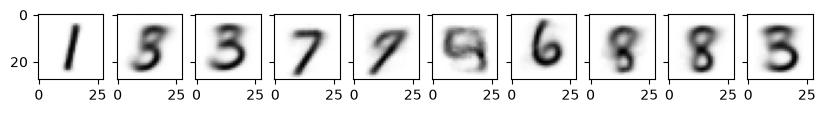

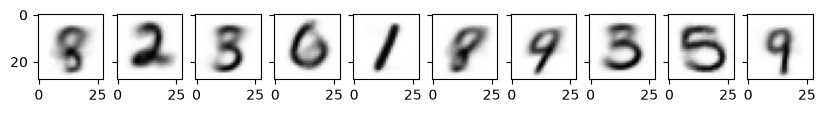

In [24]:
for i in range(10):
    plot_images_sampled_from_vae(model=model, device=DEVICE, latent_size=2)
    plt.show()